# Evaluasi Model — Klasifikasi Amar Putusan

Notebook ini mengevaluasi performa dua jenis tugas:
1. **Retrieval** — TF-IDF + Cosine vs IndoBERT + Cosine
2. **Prediction** — TF-IDF + SVM vs TF-IDF + Reuse

---

## 1. Import Library
Import semua library yang diperlukan: pandas, numpy, sklearn, transformers, matplotlib, dsb.

In [1]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

import os
import joblib
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModel
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix

)

from sklearn.metrics.pairwise import (
    cosine_similarity
)

c:\Users\ADHIM\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset
Memuat dataset `cases.csv` dari folder data/processed dan menampilkan preview awal.

In [2]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    "../data/processed/cases.csv"
)

df = df.fillna("")

print(df.shape)

df.head()

(100, 10)


,case_id,file_name,no_perkara,tanggal,pasal,ringkasan_fakta,amar_putusan,jumlah_kata,jumlah_karakter,text_full
0,1,case_001.txt,1013 k pid.sus 2026,2025-08-07,"pasal 2, pasal 76, pasal 88",berdasarkan fakta hukum yang relevan secara yu...,mengadili telah dilaksanakan menurut ketentu...,1351,9333,gnomor 1013 k pid.sus 2026 memeriksa perkara t...
1,2,case_002.txt,1013 k pid.sus 2026,2025-08-07,"pasal 2, pasal 76, pasal 88",berdasarkan fakta hukum yang relevan secara yu...,mengadili telah dilaksanakan menurut ketentu...,1351,9333,gnomor 1013 k pid.sus 2026 memeriksa perkara t...
2,3,case_003.txt,Tidak Ditemukan,2026-04-06,"pasal 1, pasal 17, pasal 204, pasal 250, pasal...","berdasarkan fakta hukum tersebut di atas, terd...",mengadili perkara pidana dengan acara pemeri...,21672,138199,nomor 103 pid.sus 2025 pn pts pengadilan n...
3,4,case_004.txt,1092 k pid 2024,2024-03-06,"pasal 12, pasal 2, pasal 30",gnomor 1092 k pid 2024 memeriksa perkara tinda...,dinyatakan ditolak dengan perbaikan e menimnba...,1230,8511,gnomor 1092 k pid 2024 memeriksa perkara tinda...
4,5,case_005.txt,1153 pk pid.sus 2024,2024-08-07,"pasal 2, pasal 263, pasal 266, pasal 296, pasa...",gnomor 1153 pk pid.sus 2024 memeriksa perkara ...,dinyatakan ditolak dan putusan yang dimohonkan...,882,6185,gnomor 1153 pk pid.sus 2024 memeriksa perkara ...


## 3. Penyederhanaan Label Amar Putusan
Fungsi `simplify_amar()` memetakan teks amar putusan panjang menjadi kategori singkat (ditolak, dikabulkan, dsb).

In [3]:
# ============================================================
# AMAR PUTUSAN SINGKAT
# ============================================================

def simplify_amar(text):

    text = str(text).lower()

    if "ditolak dengan perbaikan" in text:
        return "ditolak dengan perbaikan"

    elif "dinyatakan ditolak" in text:
        return "dinyatakan ditolak"

    elif "menolak permohonan" in text:
        return "menolak permohonan"

    elif "mengabulkan permohonan" in text:
        return "mengabulkan permohonan"

    elif "mengadili" in text:
        return "mengadili"

    return "lainnya"


df["amar_singkat"] = df["amar_putusan"].apply(
    simplify_amar
)

## 4. Pembuatan Kolom Retrieval Text
Menggabungkan kolom `pasal`, `ringkasan_fakta`, dan `text_full` menjadi satu kolom teks untuk proses retrieval.

In [4]:
# ============================================================
# RETRIEVAL TEXT
# ============================================================

df["retrieval_text"] = (

    df["pasal"].astype(str)

    + " "

    + df["ringkasan_fakta"].astype(str)

    + " "

    + df["text_full"].astype(str).str[:5000]

)

## 5. Pembagian Data: Train dan Test
Membagi dataset menjadi 80% train dan 20% test dengan stratifikasi berdasarkan `amar_singkat`.

In [5]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(

    df,

    test_size=0.20,

    random_state=42,

    stratify=df["amar_singkat"]

)

print("Train :", len(train_df))
print("Test  :", len(test_df))

Train : 80
Test  : 20


---
## 6. Persiapan Model
### 6.1 Load Model TF-IDF dan SVM
Memuat vectorizer TF-IDF dan model SVM yang sudah ditraining dari folder `models/`.

In [6]:
# ============================================================
# LOAD MODEL
# ============================================================

vectorizer = joblib.load(
    "../models/tfidf_vectorizer.pkl"
)

svm_model = joblib.load(
    "../models/svm_model.pkl"
)

print("Model berhasil dimuat")

Model berhasil dimuat


### 6.2 Transformasi TF-IDF Matrix (Train & Test)
Mengubah teks retrieval menjadi representasi vektor TF-IDF untuk data train dan test.

In [7]:
# ============================================================
# TF-IDF MATRIX
# ============================================================

X_train = vectorizer.transform(
    train_df["retrieval_text"]
)

X_test = vectorizer.transform(
    test_df["retrieval_text"]
)

### 6.3 Load Hasil Prediksi Sebelumnya
Memuat file `predictions.csv` yang berisi hasil prediksi dari pipeline sebelumnya.

In [8]:
# ============================================================
# LOAD PREDICTION RESULT
# ============================================================

pred_df = pd.read_csv(
    "../data/results/predictions.csv"
)

pred_df.head()

,query_id,predicted_solution,top_5_case_ids
0,84,mengadili,"83,39,10,36,37"
1,54,ditolak dengan perbaikan,"29,30,27,26,37"
2,71,mengadili,"25,15,94,53,68"
3,46,ditolak dengan perbaikan,"47,70,8,10,21"
4,45,dinyatakan ditolak,"10,67,48,49,62"


---
## 7. Evaluasi Retrieval — TF-IDF + Cosine Similarity
### 7.1 Fungsi Retrieve TF-IDF
Fungsi untuk mengambil Top-K dokumen paling relevan menggunakan cosine similarity berbasis TF-IDF.

In [9]:
# ============================================================
# RETRIEVE TF-IDF
# ============================================================

def retrieve_tfidf(
    query,
    k=5
):

    query_vector = vectorizer.transform(
        [query]
    )

    scores = cosine_similarity(

        query_vector,

        X_train

    )[0]

    top_idx = np.argsort(
        scores
    )[::-1][:k]

    return train_df.iloc[
        top_idx
    ]["case_id"].tolist()

### 7.2 Hitung Hit@5 Accuracy — TF-IDF
Mengevaluasi retrieval dengan metrik Hit@5: apakah label yang benar ada di antara 5 dokumen teratas?

In [10]:
# ============================================================
# EVALUASI TF-IDF RETRIEVAL
# ============================================================

hit_count = 0

for _, row in test_df.iterrows():

    retrieved = retrieve_tfidf(

        row["retrieval_text"],

        k=5

    )

    retrieved_rows = train_df[
        train_df["case_id"].isin(retrieved)
    ]

    retrieved_labels = retrieved_rows[
        "amar_singkat"
    ].tolist()

    if row["amar_singkat"] in retrieved_labels:

        hit_count += 1

tfidf_accuracy = hit_count / len(test_df)

print(
    f"TF-IDF Hit@5 : {tfidf_accuracy:.2%}"
)

TF-IDF Hit@5 : 100.00%


---
## 8. Evaluasi Retrieval — IndoBERT + Cosine Similarity
### 8.1 Load Model IndoBERT
Memuat tokenizer dan model IndoBERT (`indobenchmark/indobert-base-p1`) dari HuggingFace.

In [11]:
MODEL_NAME = (
    "indobenchmark/indobert-base-p1"
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModel.from_pretrained(
    MODEL_NAME
)

model.eval()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 49703.24it/s]


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(50000, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout): Dropout(p=

### 8.2 Fungsi Get Embedding
Fungsi untuk mengubah teks menjadi embedding vektor menggunakan IndoBERT (mean pooling CLS token).

In [12]:
def get_embedding(text):

    inputs = tokenizer(

        str(text)[:512],

        return_tensors="pt",

        truncation=True,

        padding=True,

        max_length=512

    )

    with torch.no_grad():

        outputs = model(**inputs)

    return (

        outputs.last_hidden_state

        .mean(dim=1)

        .squeeze()

        .numpy()

    )

### 8.3 Buat Embedding Seluruh Data Train
Menghasilkan embedding untuk semua dokumen di data train — digunakan sebagai basis pencarian.

In [13]:
train_embeddings = np.array([

    get_embedding(text)

    for text in train_df["retrieval_text"]

])

### 8.4 Fungsi Retrieve IndoBERT
Fungsi retrieval yang mencari Top-K dokumen paling mirip menggunakan cosine similarity antar embedding IndoBERT.

In [14]:
def retrieve_bert(
    query,
    k=5
):

    query_embedding = get_embedding(
        query
    )

    similarities = cosine_similarity(

        [query_embedding],

        train_embeddings

    )[0]

    top_idx = np.argsort(
        similarities
    )[::-1][:k]

    return train_df.iloc[
        top_idx
    ]["case_id"].tolist()

### 8.5 Hitung Hit@5 Accuracy — IndoBERT
Mengevaluasi performa retrieval IndoBERT dengan metrik Hit@5 pada data test.

In [15]:
hit_count = 0

for _, row in test_df.iterrows():

    retrieved = retrieve_bert(

        row["retrieval_text"],

        k=5

    )

    retrieved_rows = train_df[
        train_df["case_id"].isin(retrieved)
    ]

    retrieved_labels = retrieved_rows[
        "amar_singkat"
    ].tolist()

    if row["amar_singkat"] in retrieved_labels:

        hit_count += 1

bert_accuracy = hit_count / len(test_df)

print(
    f"IndoBERT Hit@5 : {bert_accuracy:.2%}"
)

IndoBERT Hit@5 : 90.00%


---
## 9. Evaluasi Prediksi — TF-IDF + SVM
Menghitung metrik evaluasi SVM (Accuracy, Precision, Recall, F1) pada data test.

In [16]:
svm_pred = svm_model.predict(
    X_test
)

svm_accuracy = accuracy_score(
    test_df["amar_singkat"],
    svm_pred
)

svm_precision = precision_score(
    test_df["amar_singkat"],
    svm_pred,
    average="weighted",
    zero_division=0
)

svm_recall = recall_score(
    test_df["amar_singkat"],
    svm_pred,
    average="weighted",
    zero_division=0
)

svm_f1 = f1_score(
    test_df["amar_singkat"],
    svm_pred,
    average="weighted",
    zero_division=0
)

## 10. Evaluasi Prediksi — TF-IDF + Reuse (Pipeline)
Mengevaluasi hasil prediksi dari pipeline reuse (menggunakan `predictions.csv`) terhadap label sebenarnya.

In [17]:
actual = []

for _, row in pred_df.iterrows():

    case_id = row["query_id"]

    actual.append(

        df.loc[
            df["case_id"] == case_id,
            "amar_singkat"
        ].values[0]

    )

prediction_accuracy = accuracy_score(
    actual,
    pred_df["predicted_solution"]
)

prediction_precision = precision_score(
    actual,
    pred_df["predicted_solution"],
    average="weighted",
    zero_division=0
)

prediction_recall = recall_score(
    actual,
    pred_df["predicted_solution"],
    average="weighted",
    zero_division=0
)

prediction_f1 = f1_score(
    actual,
    pred_df["predicted_solution"],
    average="weighted",
    zero_division=0
)

---
## 11. Tabel Ringkasan Metrik
### 11.1 Tabel Metrik Retrieval
Menampilkan perbandingan Hit@5 Accuracy antara TF-IDF dan IndoBERT.

In [18]:
retrieval_metrics = pd.DataFrame({

    "Model":[

        "TF-IDF + Cosine",

        "IndoBERT + Cosine"

    ],

    "Hit@5 Accuracy":[

        tfidf_accuracy,

        bert_accuracy

    ]

})

retrieval_metrics

,Model,Hit@5 Accuracy
0,TF-IDF + Cosine,1.0
1,IndoBERT + Cosine,0.9


### 11.2 Tabel Metrik Prediction
Menampilkan Accuracy, Precision, Recall, dan F1 untuk model SVM dan Reuse.

In [19]:
prediction_metrics = pd.DataFrame({

    "Model":[

        "TF-IDF + SVM",

        "TF-IDF + Reuse"

    ],

    "Accuracy":[

        svm_accuracy,

        prediction_accuracy

    ],

    "Precision":[

        svm_precision,

        prediction_precision

    ],

    "Recall":[

        svm_recall,

        prediction_recall

    ],

    "F1":[

        svm_f1,

        prediction_f1

    ]

})

prediction_metrics

,Model,Accuracy,Precision,Recall,F1
0,TF-IDF + SVM,0.95,0.908333,0.95,0.927273
1,TF-IDF + Reuse,0.75,0.650000,0.75,0.690000


### 11.3 Tabel Perbandingan Akhir Seluruh Model
Ringkasan accuracy semua model dalam satu tabel perbandingan.

In [20]:
final_comparison = pd.DataFrame({

    "Model":[

        "TF-IDF + Cosine",

        "IndoBERT + Cosine",

        "TF-IDF + SVM",

        "TF-IDF + Reuse"

    ],

    "Jenis":[

        "Retrieval",

        "Retrieval",

        "Prediction",

        "Prediction"

    ],

     "Accuracy":[
        tfidf_accuracy,
        bert_accuracy,
        svm_accuracy,
        prediction_accuracy
    ]

})

final_comparison

,Model,Jenis,Accuracy
0,TF-IDF + Cosine,Retrieval,1.00
1,IndoBERT + Cosine,Retrieval,0.90
2,TF-IDF + SVM,Prediction,0.95
3,TF-IDF + Reuse,Prediction,0.75


### 11.4 Tabel Lengkap dengan Semua Metrik
Tabel komprehensif mencakup semua model beserta metrik Precision, Recall, dan F1 Score.

In [21]:

# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({

    "Model":[

        "TF-IDF + Cosine",

        "IndoBERT + Cosine",

        "TF-IDF + SVM",

        "TF-IDF + Reuse"

    ],

    "Jenis":[

        "Retrieval",

        "Retrieval",

        "Prediction",

        "Prediction"

    ],

    "Accuracy":[

        tfidf_accuracy,      # Hit@5 TF-IDF

        bert_accuracy,       # Hit@5 IndoBERT

        svm_accuracy,

        prediction_accuracy

    ],

    "Precision":[

        "",

        "",

        svm_precision,

        prediction_precision

    ],

    "Recall":[

        "",

        "",

        svm_recall,

        prediction_recall

    ],

    "F1 Score":[

        "",

        "",

        svm_f1,

        prediction_f1

    ]

})

model_comparison

,Model,Jenis,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Cosine,Retrieval,1.00,,,
1,IndoBERT + Cosine,Retrieval,0.90,,,
2,TF-IDF + SVM,Prediction,0.95,0.908333,0.95,0.927273
3,TF-IDF + Reuse,Prediction,0.75,0.65,0.75,0.69


---
## 12. Analisis Error Prediksi
### 12.1 Identifikasi Kasus Salah Prediksi
Memisahkan kasus-kasus yang prediksinya tidak sesuai dengan label sebenarnya.

In [22]:
pred_df["actual"] = actual

error_df = pred_df[

    pred_df["actual"]

    !=

    pred_df["predicted_solution"]

]

print(
    "Jumlah Error :",
    len(error_df)
)

error_df.head(10)

Jumlah Error : 5


,query_id,predicted_solution,top_5_case_ids,actual
4,45,dinyatakan ditolak,"10,67,48,49,62",menolak permohonan
5,40,mengadili,"89,25,3,70,15",menolak permohonan
12,74,ditolak dengan perbaikan,"75,21,22,41,37",mengadili
18,13,ditolak dengan perbaikan,"14,41,36,37,96",dinyatakan ditolak
19,32,ditolak dengan perbaikan,"33,37,36,35,10",lainnya


### 12.2 Ringkasan Pola Error (Actual vs Predicted)
Menampilkan pola kesalahan prediksi: kombinasi label aktual dan label yang diprediksi.

In [23]:
error_summary = (
    error_df
    .groupby(
        ["actual","predicted_solution"]
    )
    .size()
    .reset_index(name="jumlah")
)

error_summary

,actual,predicted_solution,jumlah
0,dinyatakan ditolak,ditolak dengan perbaikan,1
1,lainnya,ditolak dengan perbaikan,1
2,mengadili,ditolak dengan perbaikan,1
3,menolak permohonan,dinyatakan ditolak,1
4,menolak permohonan,mengadili,1


### 12.3 Kasus yang Diprediksi Benar
Menampilkan semua kasus yang berhasil diprediksi dengan benar.

In [24]:
# ============================================================
# KASUS BENAR
# ============================================================

correct_df = pred_df[

    pred_df["actual"]

    ==

    pred_df["predicted_solution"]

]

print(
    "Jumlah Benar :",
    len(correct_df)
)

display(correct_df)

Jumlah Benar : 15


,query_id,predicted_solution,top_5_case_ids,actual
0,84,mengadili,"83,39,10,36,37",mengadili
1,54,ditolak dengan perbaikan,"29,30,27,26,37",ditolak dengan perbaikan
2,71,mengadili,"25,15,94,53,68",mengadili
3,46,ditolak dengan perbaikan,"47,70,8,10,21",ditolak dengan perbaikan
6,23,ditolak dengan perbaikan,"24,10,22,21,37",ditolak dengan perbaikan
7,81,ditolak dengan perbaikan,"36,37,10,27,26",ditolak dengan perbaikan
8,11,ditolak dengan perbaikan,"10,26,27,8,36",ditolak dengan perbaikan
9,1,mengadili,"2,10,37,36,22",mengadili
10,19,ditolak dengan perbaikan,"20,21,22,18,17",ditolak dengan perbaikan
11,31,mengadili,"25,15,72,42,58",mengadili


### 12.4 Semua Hasil Prediksi dengan Status
Menampilkan seluruh hasil prediksi dengan kolom status 'Benar' atau 'Salah'.

In [25]:
# ============================================================
# SEMUA HASIL PREDIKSI
# ============================================================

pred_df["status"] = np.where(

    pred_df["actual"]
    ==
    pred_df["predicted_solution"],

    "Benar",

    "Salah"

)

display(pred_df)

,query_id,predicted_solution,top_5_case_ids,actual,status
0,84,mengadili,"83,39,10,36,37",mengadili,Benar
1,54,ditolak dengan perbaikan,"29,30,27,26,37",ditolak dengan perbaikan,Benar
2,71,mengadili,"25,15,94,53,68",mengadili,Benar
3,46,ditolak dengan perbaikan,"47,70,8,10,21",ditolak dengan perbaikan,Benar
4,45,dinyatakan ditolak,"10,67,48,49,62",menolak permohonan,Salah
5,40,mengadili,"89,25,3,70,15",menolak permohonan,Salah
6,23,ditolak dengan perbaikan,"24,10,22,21,37",ditolak dengan perbaikan,Benar
7,81,ditolak dengan perbaikan,"36,37,10,27,26",ditolak dengan perbaikan,Benar
8,11,ditolak dengan perbaikan,"10,26,27,8,36",ditolak dengan perbaikan,Benar
9,1,mengadili,"2,10,37,36,22",mengadili,Benar


---
## 13. Visualisasi Hasil Evaluasi
### 13.1 Bar Chart — Perbandingan Retrieval (TF-IDF vs IndoBERT)
Visualisasi Hit@5 Accuracy untuk model TF-IDF + Cosine dan IndoBERT + Cosine.

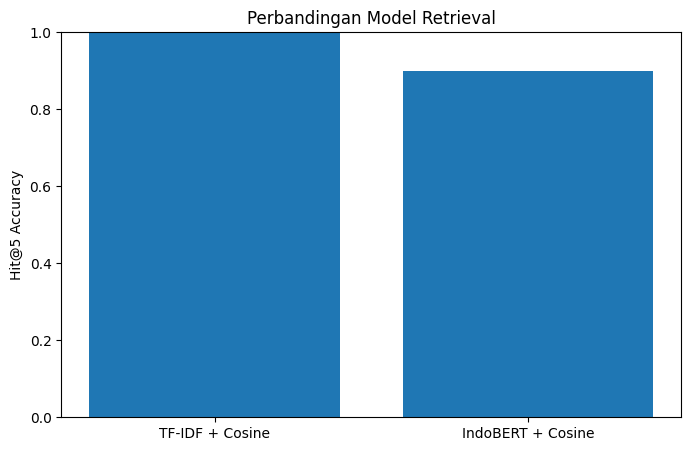

In [26]:
# ============================================================
# VISUALISASI RETRIEVAL
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(

    retrieval_metrics["Model"],

    retrieval_metrics["Hit@5 Accuracy"]

)

plt.title(
    "Perbandingan Model Retrieval"
)

plt.ylabel(
    "Hit@5 Accuracy"
)

plt.ylim(0,1)

plt.show()

### 13.2 Bar Chart — Perbandingan Metrik Prediction (SVM vs Reuse)
Visualisasi Accuracy, Precision, Recall, dan F1 untuk dua model prediksi.

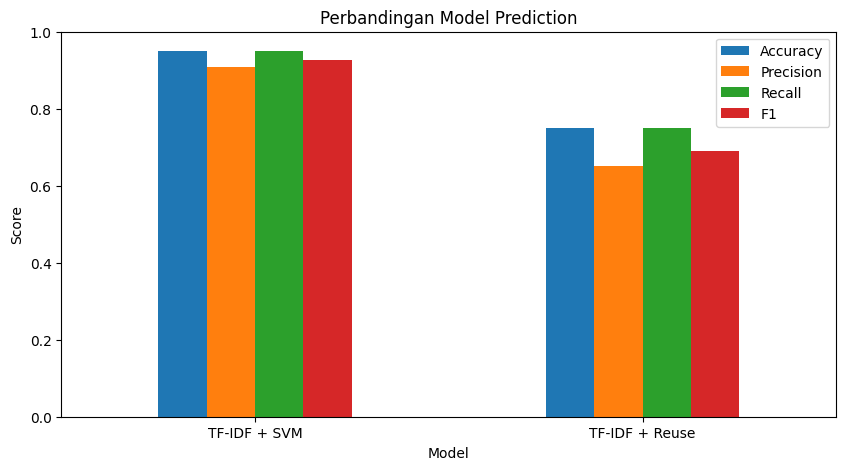

In [27]:
# ============================================================
# VISUALISASI PREDICTION
# ============================================================

prediction_plot = prediction_metrics.set_index(
    "Model"
)

prediction_plot.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Perbandingan Model Prediction"
)

plt.ylabel(
    "Score"
)

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.show()

### 13.3 Bar Chart — Perbandingan Seluruh Model (Overall)
Visualisasi accuracy semua model (retrieval dan prediction) dalam satu grafik.

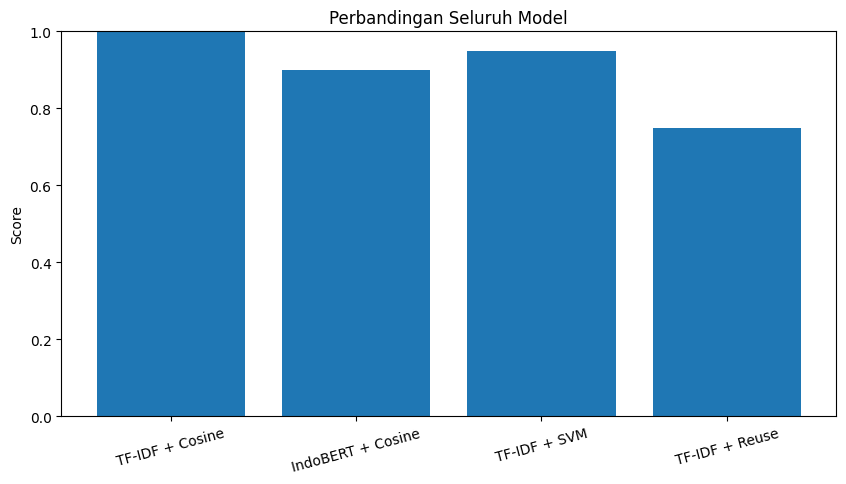

In [28]:
# ============================================================
# OVERALL MODEL COMPARISON
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(

    final_comparison["Model"],

    final_comparison["Accuracy"]

)

plt.title(
    "Perbandingan Seluruh Model"
)

plt.ylabel(
    "Score"
)

plt.ylim(0,1)

plt.xticks(rotation=15)

plt.show()

### 13.4 Bar Chart — Distribusi Kelas Amar Putusan
Visualisasi distribusi label `amar_singkat` pada keseluruhan dataset.

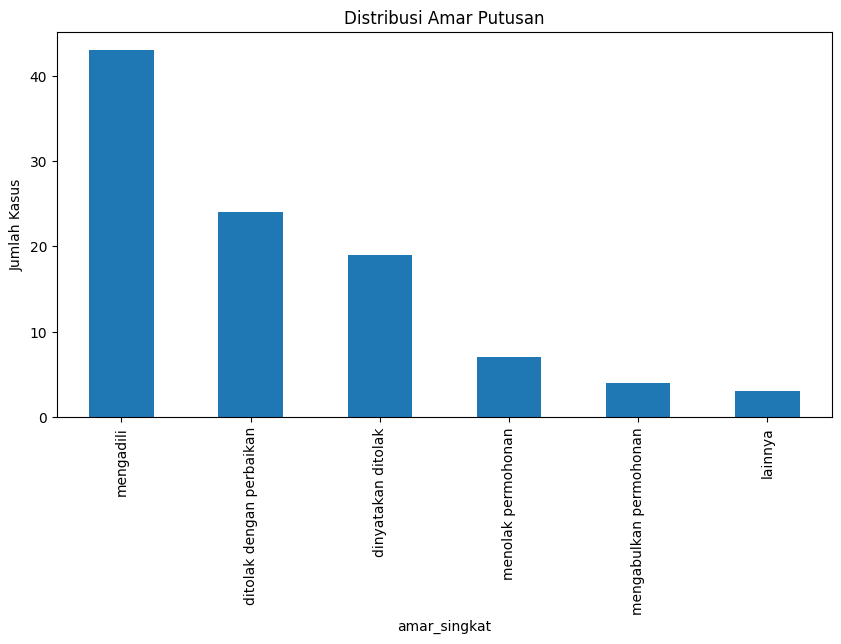

In [29]:
# ============================================================
# DISTRIBUSI KELAS
# ============================================================

df["amar_singkat"].value_counts().plot(

    kind="bar",

    figsize=(10,5)

)

plt.title(
    "Distribusi Amar Putusan"
)

plt.ylabel(
    "Jumlah Kasus"
)

plt.show()

### 13.5 Confusion Matrix — SVM
Confusion matrix untuk model TF-IDF + SVM: melihat distribusi prediksi benar dan salah per kelas.

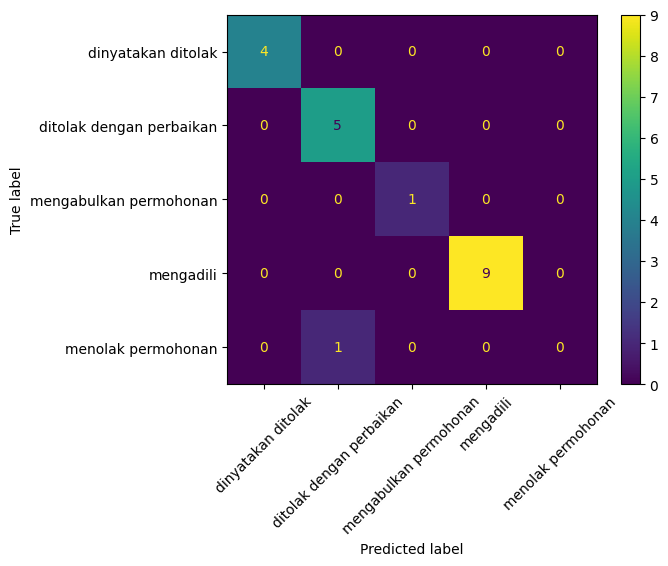

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    test_df["amar_singkat"],
    svm_pred,
    xticks_rotation=45
)

plt.show()

### 13.6 Pie Chart — Proporsi Prediksi Benar vs Salah
Visualisasi persentase prediksi benar dan salah dari pipeline reuse.

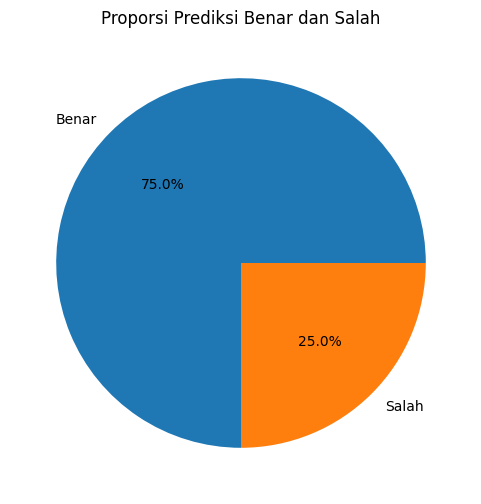

In [31]:
# ============================================================
# ERROR ANALYSIS
# ============================================================

error_count = len(error_df)

correct_count = len(pred_df) - error_count

plt.figure(figsize=(6,6))

plt.pie(

    [correct_count, error_count],

    labels=["Benar", "Salah"],

    autopct="%1.1f%%"

)

plt.title(
    "Proporsi Prediksi Benar dan Salah"
)

plt.show()

---
## 14. Simpan Hasil Evaluasi
Menyimpan tabel metrik retrieval dan prediction ke folder `data/eval/` dalam format CSV.

In [32]:
os.makedirs(
    "../data/eval",
    exist_ok=True
)

retrieval_metrics.to_csv(

    "../data/eval/retrieval_metrics.csv",

    index=False

)

prediction_metrics.to_csv(

    "../data/eval/prediction_metrics.csv",

    index=False

)

print("Evaluasi berhasil disimpan")

Evaluasi berhasil disimpan


---
*Evaluasi selesai. Hasil tersimpan di `data/eval/`.*